In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import string

# Import NLP libraries
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.util import ngrams

# Import spaCy for advanced NLP capabilities
# Setup Instructions:
# 1. Install spaCy: pip install spacy
# 2. Download English model: python -m spacy download en_core_web_sm
# 3. For better accuracy, download medium model: python -m spacy download en_core_web_md

import spacy
# Load English language model
nlp = spacy.load("en_core_web_sm")

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

from wordcloud import WordCloud
import plotly.express as px
import plotly.graph_objects as go

# Download required NLTK data (run once)
# nltk.download('punkt')
# nltk.download('stopwords')
# nltk.download('wordnet')
# nltk.download('averaged_perceptron_tagger')

In [2]:
# To illustrate text analysis methods, we will use the speech given by Geoffrey Hinton, Godfather of AI, at the awards ceremony of the 2024 Nobel Prize in Physics.
# https://www.nobelprize.org/prizes/physics/2024/hinton/speech/
speech = ['This year the Nobel committees in Physics and Chemistry have recognized the dramatic progress being made in a new form of Artificial Intelligence that uses artificial neural networks to learn how to solve difficult computational problems.',
 'This new form of AI excels at modeling human intuition rather than human reasoning and it will enable us to create highly intelligent and knowledgeable assistants who will increase productivity in almost all industries.',
 'If the benefits of the increased productivity can be shared equally it will be a wonderful advance for all humanity.',
 'Unfortunately, the rapid progress in AI comes with many short-term risks.',
 'It has already created divisive echo-chambers by offering people content that makes them indignant.',
 'It is already being used by authoritarian governments for massive surveillance and by cyber criminals for phishing attacks.',
 'In the near future AI may be used to create terrible new viruses and horrendous lethal weapons that decide by themselves who to kill or maim.',
 'All of these short-term risks require urgent and forceful attention from governments and international organizations.',
 'There is also a longer term existential threat that will arise when we create digital beings that are more intelligent than ourselves.',
 'We have no idea whether we can stay in control.',
 'But we now have evidence that if they are created by companies motivated by short-term profits, our safety will not be the top priority.',
 'We urgently need research on how to prevent these new beings from wanting to take control.',
 'They are no longer science fiction.']

cleaned_speech = []
for sentence in speech:
    sentence = re.sub(r'<[^>]+>', '', sentence)  # Remove HTML tags (if any)
    sentence = re.sub(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', '', sentence) # Remove URLs
    sentence = re.sub(r'\d+', '', sentence)  # Remove numbers (keeping text intact)
    sentence = re.sub(r'\s+', ' ', sentence).strip() # Remove extra whitespace
    sentence = sentence.lower()  # Convert to lowercase
    cleaned_speech.append(sentence)
cleaned_speech

['this year the nobel committees in physics and chemistry have recognized the dramatic progress being made in a new form of artificial intelligence that uses artificial neural networks to learn how to solve difficult computational problems.',
 'this new form of ai excels at modeling human intuition rather than human reasoning and it will enable us to create highly intelligent and knowledgeable assistants who will increase productivity in almost all industries.',
 'if the benefits of the increased productivity can be shared equally it will be a wonderful advance for all humanity.',
 'unfortunately, the rapid progress in ai comes with many short-term risks.',
 'it has already created divisive echo-chambers by offering people content that makes them indignant.',
 'it is already being used by authoritarian governments for massive surveillance and by cyber criminals for phishing attacks.',
 'in the near future ai may be used to create terrible new viruses and horrendous lethal weapons that 

In [3]:
word_tokenize('they are no longer science fiction.')

['they', 'are', 'no', 'longer', 'science', 'fiction', '.']

In [4]:
word_tokenize(cleaned_speech[-1])

['they', 'are', 'no', 'longer', 'science', 'fiction', '.']

In [5]:
[print(word_tokenize(sentence)) for sentence in cleaned_speech]

['this', 'year', 'the', 'nobel', 'committees', 'in', 'physics', 'and', 'chemistry', 'have', 'recognized', 'the', 'dramatic', 'progress', 'being', 'made', 'in', 'a', 'new', 'form', 'of', 'artificial', 'intelligence', 'that', 'uses', 'artificial', 'neural', 'networks', 'to', 'learn', 'how', 'to', 'solve', 'difficult', 'computational', 'problems', '.']
['this', 'new', 'form', 'of', 'ai', 'excels', 'at', 'modeling', 'human', 'intuition', 'rather', 'than', 'human', 'reasoning', 'and', 'it', 'will', 'enable', 'us', 'to', 'create', 'highly', 'intelligent', 'and', 'knowledgeable', 'assistants', 'who', 'will', 'increase', 'productivity', 'in', 'almost', 'all', 'industries', '.']
['if', 'the', 'benefits', 'of', 'the', 'increased', 'productivity', 'can', 'be', 'shared', 'equally', 'it', 'will', 'be', 'a', 'wonderful', 'advance', 'for', 'all', 'humanity', '.']
['unfortunately', ',', 'the', 'rapid', 'progress', 'in', 'ai', 'comes', 'with', 'many', 'short-term', 'risks', '.']
['it', 'has', 'already'

[None, None, None, None, None, None, None, None, None, None, None, None, None]

In [6]:
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [7]:
word_tokens=[word_tokenize(sentence) for sentence in cleaned_speech]
filtered_tokens=[]
for tokens in word_tokens:
    filtered=[word for word in tokens if word.lower() not in stopwords.words('english')]
    filtered_tokens.append(filtered)

In [8]:
filtered_tokens

[['year',
  'nobel',
  'committees',
  'physics',
  'chemistry',
  'recognized',
  'dramatic',
  'progress',
  'made',
  'new',
  'form',
  'artificial',
  'intelligence',
  'uses',
  'artificial',
  'neural',
  'networks',
  'learn',
  'solve',
  'difficult',
  'computational',
  'problems',
  '.'],
 ['new',
  'form',
  'ai',
  'excels',
  'modeling',
  'human',
  'intuition',
  'rather',
  'human',
  'reasoning',
  'enable',
  'us',
  'create',
  'highly',
  'intelligent',
  'knowledgeable',
  'assistants',
  'increase',
  'productivity',
  'almost',
  'industries',
  '.'],
 ['benefits',
  'increased',
  'productivity',
  'shared',
  'equally',
  'wonderful',
  'advance',
  'humanity',
  '.'],
 ['unfortunately',
  ',',
  'rapid',
  'progress',
  'ai',
  'comes',
  'many',
  'short-term',
  'risks',
  '.'],
 ['already',
  'created',
  'divisive',
  'echo-chambers',
  'offering',
  'people',
  'content',
  'makes',
  'indignant',
  '.'],
 ['already',
  'used',
  'authoritarian',
  'gov

In [9]:
print(word_tokens[0],
      '\n',
      '--------------------------------',
      '\n',
      filtered_tokens[0])

['this', 'year', 'the', 'nobel', 'committees', 'in', 'physics', 'and', 'chemistry', 'have', 'recognized', 'the', 'dramatic', 'progress', 'being', 'made', 'in', 'a', 'new', 'form', 'of', 'artificial', 'intelligence', 'that', 'uses', 'artificial', 'neural', 'networks', 'to', 'learn', 'how', 'to', 'solve', 'difficult', 'computational', 'problems', '.'] 
 -------------------------------- 
 ['year', 'nobel', 'committees', 'physics', 'chemistry', 'recognized', 'dramatic', 'progress', 'made', 'new', 'form', 'artificial', 'intelligence', 'uses', 'artificial', 'neural', 'networks', 'learn', 'solve', 'difficult', 'computational', 'problems', '.']


In [10]:
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

example_words = ['running', 'better', 'studies', 'amazing', 'processing']
[(word, stemmer.stem(word),lemmatizer.lemmatize(word)) for word in example_words]

[('running', 'run', 'running'),
 ('better', 'better', 'better'),
 ('studies', 'studi', 'study'),
 ('amazing', 'amaz', 'amazing'),
 ('processing', 'process', 'processing')]

In [11]:
stemmed_tokens = []
lemmatized_tokens = []
for tokens in filtered_tokens:
    stemmed = [stemmer.stem(word) for word in tokens]
    lemmatized = [lemmatizer.lemmatize(word) for word in tokens]
    stemmed_tokens.append(stemmed)
    lemmatized_tokens.append(lemmatized)

In [12]:
print(word_tokens[0],
      '\n',
      '--------------------------------',
      '\n',
      stemmed_tokens[0],
      '\n',
      '--------------------------------',
      '\n',
     lemmatized_tokens[0])

['this', 'year', 'the', 'nobel', 'committees', 'in', 'physics', 'and', 'chemistry', 'have', 'recognized', 'the', 'dramatic', 'progress', 'being', 'made', 'in', 'a', 'new', 'form', 'of', 'artificial', 'intelligence', 'that', 'uses', 'artificial', 'neural', 'networks', 'to', 'learn', 'how', 'to', 'solve', 'difficult', 'computational', 'problems', '.'] 
 -------------------------------- 
 ['year', 'nobel', 'committe', 'physic', 'chemistri', 'recogn', 'dramat', 'progress', 'made', 'new', 'form', 'artifici', 'intellig', 'use', 'artifici', 'neural', 'network', 'learn', 'solv', 'difficult', 'comput', 'problem', '.'] 
 -------------------------------- 
 ['year', 'nobel', 'committee', 'physic', 'chemistry', 'recognized', 'dramatic', 'progress', 'made', 'new', 'form', 'artificial', 'intelligence', 'us', 'artificial', 'neural', 'network', 'learn', 'solve', 'difficult', 'computational', 'problem', '.']


In [13]:
vectorizer = CountVectorizer(
    lowercase=True,
    stop_words='english',
    max_features=50,  # Limit to top 50 features
    ngram_range=(1, 2))  # Include unigrams and bigrams
bow_matrix = vectorizer.fit_transform(cleaned_speech)

# Convert to dense array for easier viewing
bow_array = bow_matrix.toarray()

print("Bag of Words Matrix Shape:", bow_matrix.shape,'\n',
     "Feature names (vocabulary):",
      vectorizer.get_feature_names_out())

# Create a DataFrame for better visualization
bow_df = pd.DataFrame(bow_array,
                      columns=vectorizer.get_feature_names_out())
bow_df.iloc[:,:10]

Bag of Words Matrix Shape: (13, 50) 
 Feature names (vocabulary): ['advance humanity' 'ai' 'ai excels' 'arise create' 'artificial'
 'artificial intelligence' 'artificial neural' 'attention governments'
 'authoritarian' 'authoritarian governments' 'beings' 'beings intelligent'
 'beings wanting' 'benefits' 'committees' 'committees physics' 'companies'
 'companies motivated' 'computational' 'computational problems' 'content'
 'content makes' 'control' 'create' 'create digital' 'create highly'
 'create terrible' 'created' 'created companies' 'created divisive'
 'criminals' 'criminals phishing' 'cyber' 'cyber criminals' 'decide'
 'form' 'governments' 'human' 'intelligent' 'longer' 'new' 'new form'
 'productivity' 'progress' 'risks' 'short' 'short term' 'term'
 'term risks' 'used']


,advance humanity,ai,ai excels,arise create,artificial,artificial intelligence,artificial neural,attention governments,authoritarian,authoritarian governments
0,0,0,0,0,2,1,1,0,0,0
1,0,1,1,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0
3,0,1,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,1,1
6,0,1,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,1,0,0
8,0,0,0,1,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0


In [14]:
tfidf_vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    max_features=50,
    ngram_range=(1, 2))

# Fit and transform the cleaned texts
tfidf_matrix = tfidf_vectorizer.fit_transform(cleaned_speech)
tfidf_array = tfidf_matrix.toarray()

# Create a DataFrame for TF-IDF
tfidf_df = pd.DataFrame(
    tfidf_array,
    columns=tfidf_vectorizer.get_feature_names_out())
tfidf_df.iloc[:,:10]

,advance humanity,ai,ai excels,arise create,artificial,artificial intelligence,artificial neural,attention governments,authoritarian,authoritarian governments
0,0.000000,0.000000,0.000000,0.000000,0.561088,0.280544,0.280544,0.0000,0.000000,0.000000
1,0.000000,0.234669,0.306874,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000
2,0.603718,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000
3,0.000000,0.362099,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000
5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.365457,0.365457
6,0.000000,0.365063,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000
7,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.4529,0.000000,0.000000
8,0.000000,0.000000,0.000000,0.398712,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000
9,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000


# Class 4/7/2026

In [18]:
import os
os.chdir('../')

In [19]:


import pandas as pd
data=pd.read_csv('Datasets/video_game_reviews.csv').set_index('id')
X=data.review
y=data.review_rating
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=0.7,random_state=1031)

In [20]:
vectorizer=CountVectorizer(lowercase=True,stop_words='english',ngram_range=(1,1))
vectorizer.fit(X_train)

,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"stop_words stop_words: {'english'}, list, default=NoneIf 'english', a built-in stop word list for English is used.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",'english'
,"token_pattern token_pattern: str or None, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp select tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentword n-grams or char n-grams to be extracted. All values of n suchsuch that min_n <= n <= max_n will be used. For example an``ngram_range`` of ``(1, 1)`` means only unigrams, ``(1, 2)`` meansunigrams and bigrams, and ``(2, 2)`` means only bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word n-gram or charactern-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21Since v0.21, if ``input`` is ``filename`` or ``file``, the data isfirst read from the file and then passed to the given callableanalyzer.",'word'


In [29]:
# tf_train=pd.DataFrame(vectorizer.transform(X_train),columns=vectorizer.get_feature_names_out())
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    min_df=5,
    max_df=0.9
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [30]:
from sklearn.linear_model import LinearRegression

reg=LinearRegression().fit(X_train_vec,y_train)
y_pred_train=reg.predict(X_train_vec)

In [32]:
from sklearn.metrics import root_mean_squared_error
root_mean_squared_error(y_train,y_pred_train)

0.7221533641958165

In [36]:
y_pred_test=reg.predict(X_test_vec)
root_mean_squared_error(y_test,y_pred_test)

1.029304391576971

In [37]:
reg.coef_

array([-0.13210872, -0.45341727,  0.3986227 , ...,  0.36581272,
        1.56000343,  0.32658633], shape=(5000,))

In [38]:
tfidf_vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    max_features=50,
    ngram_range=(1, 2))

# Fit and transform the cleaned texts
tfidf_matrix = tfidf_vectorizer.fit_transform(cleaned_speech)
tfidf_array = tfidf_matrix.toarray()

# Create a DataFrame for TF-IDF
tfidf_df = pd.DataFrame(
    tfidf_array,
    columns=tfidf_vectorizer.get_feature_names_out())
tfidf_df.iloc[:,:10]

,advance humanity,ai,ai excels,arise create,artificial,artificial intelligence,artificial neural,attention governments,authoritarian,authoritarian governments
0,0.000000,0.000000,0.000000,0.000000,0.561088,0.280544,0.280544,0.0000,0.000000,0.000000
1,0.000000,0.234669,0.306874,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000
2,0.603718,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000
3,0.000000,0.362099,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000
5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.365457,0.365457
6,0.000000,0.365063,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000
7,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.4529,0.000000,0.000000
8,0.000000,0.000000,0.000000,0.398712,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000
9,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import string

# Import NLP libraries
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.util import ngrams

# Import spaCy for advanced NLP capabilities
# Setup Instructions:
# 1. Install spaCy: pip install spacy
# 2. Download English model: python -m spacy download en_core_web_sm
# 3. For better accuracy, download medium model: python -m spacy download en_core_web_md

import spacy
# Load English language model
nlp = spacy.load("en_core_web_sm")
# nlp = spacy.load("en_core_web_md")  # if using the medium mode.

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

from wordcloud import WordCloud
import plotly.express as px
import plotly.graph_objects as go


# Download required NLTK data (run once)
# nltk.download('punkt')
# nltk.download('punkt_tab')
# nltk.download('stopwords')
# nltk.download('wordnet')
# nltk.download('averaged_perceptron_tagger')
# nltk.download('vader_lexicon')

In [40]:
# To illustrate text analysis methods, we will use the speech given by Geoffrey Hinton, Godfather of AI, at the awards ceremony of the 2024 Nobel Prize in Physics.
# https://www.nobelprize.org/prizes/physics/2024/hinton/speech/
speech = ['This year the Nobel committees in Physics and Chemistry have recognized the dramatic progress being made in a new form of Artificial Intelligence that uses artificial neural networks to learn how to solve difficult computational problems.',
 'This new form of AI excels at modeling human intuition rather than human reasoning and it will enable us to create highly intelligent and knowledgeable assistants who will increase productivity in almost all industries.',
 'If the benefits of the increased productivity can be shared equally it will be a wonderful advance for all humanity.',
 'Unfortunately, the rapid progress in AI comes with many short-term risks.',
 'It has already created divisive echo-chambers by offering people content that makes them indignant.',
 'It is already being used by authoritarian governments for massive surveillance and by cyber criminals for phishing attacks.',
 'In the near future AI may be used to create terrible new viruses and horrendous lethal weapons that decide by themselves who to kill or maim.',
 'All of these short-term risks require urgent and forceful attention from governments and international organizations.',
 'There is also a longer term existential threat that will arise when we create digital beings that are more intelligent than ourselves.',
 'We have no idea whether we can stay in control.',
 'But we now have evidence that if they are created by companies motivated by short-term profits, our safety will not be the top priority.',
 'We urgently need research on how to prevent these new beings from wanting to take control.',
 'They are no longer science fiction.']

cleaned_speech = []
for sentence in speech:
    sentence = re.sub(r'<[^>]+>', '', sentence)  # Remove HTML tags (if any)
    sentence = re.sub(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', '', sentence) # Remove URLs
    sentence = re.sub(r'\d+', '', sentence)  # Remove numbers (keeping text intact)
    sentence = re.sub(r'\s+', ' ', sentence).strip() # Remove extra whitespace
    sentence = sentence.lower()  # Convert to lowercase
    cleaned_speech.append(sentence)
cleaned_speech

['this year the nobel committees in physics and chemistry have recognized the dramatic progress being made in a new form of artificial intelligence that uses artificial neural networks to learn how to solve difficult computational problems.',
 'this new form of ai excels at modeling human intuition rather than human reasoning and it will enable us to create highly intelligent and knowledgeable assistants who will increase productivity in almost all industries.',
 'if the benefits of the increased productivity can be shared equally it will be a wonderful advance for all humanity.',
 'unfortunately, the rapid progress in ai comes with many short-term risks.',
 'it has already created divisive echo-chambers by offering people content that makes them indignant.',
 'it is already being used by authoritarian governments for massive surveillance and by cyber criminals for phishing attacks.',
 'in the near future ai may be used to create terrible new viruses and horrendous lethal weapons that 

In [41]:
word_tokens = [word_tokenize(sentence) for sentence in speech]   # word tokens
print(word_tokens[:1])

sentence_tokens = [sent_tokenize(sentence) for sentence in speech]   # sentence tokens
print(sentence_tokens[:2])  # same as original result, because text is already broken into sentences

[['This', 'year', 'the', 'Nobel', 'committees', 'in', 'Physics', 'and', 'Chemistry', 'have', 'recognized', 'the', 'dramatic', 'progress', 'being', 'made', 'in', 'a', 'new', 'form', 'of', 'Artificial', 'Intelligence', 'that', 'uses', 'artificial', 'neural', 'networks', 'to', 'learn', 'how', 'to', 'solve', 'difficult', 'computational', 'problems', '.']]
[['This year the Nobel committees in Physics and Chemistry have recognized the dramatic progress being made in a new form of Artificial Intelligence that uses artificial neural networks to learn how to solve difficult computational problems.'], ['This new form of AI excels at modeling human intuition rather than human reasoning and it will enable us to create highly intelligent and knowledgeable assistants who will increase productivity in almost all industries.']]


In [42]:
filtered_tokens = []
for tokens in word_tokens:
    filtered = [word for word in tokens if word.lower() not in stopwords.words('english')]
    filtered_tokens.append(filtered)
print(word_tokens[0],
      '\n',
      '--------------------------------',
      '\n',
      filtered_tokens[0])

['This', 'year', 'the', 'Nobel', 'committees', 'in', 'Physics', 'and', 'Chemistry', 'have', 'recognized', 'the', 'dramatic', 'progress', 'being', 'made', 'in', 'a', 'new', 'form', 'of', 'Artificial', 'Intelligence', 'that', 'uses', 'artificial', 'neural', 'networks', 'to', 'learn', 'how', 'to', 'solve', 'difficult', 'computational', 'problems', '.'] 
 -------------------------------- 
 ['year', 'Nobel', 'committees', 'Physics', 'Chemistry', 'recognized', 'dramatic', 'progress', 'made', 'new', 'form', 'Artificial', 'Intelligence', 'uses', 'artificial', 'neural', 'networks', 'learn', 'solve', 'difficult', 'computational', 'problems', '.']


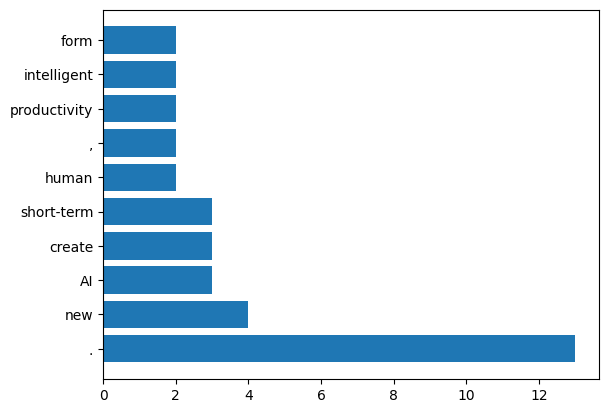

In [43]:
all_words = []
for tokens in filtered_tokens:
    all_words.extend(tokens)
df = pd.DataFrame(Counter(all_words).items(), columns=['word','n'])
df_top_10 = df.sort_values('n', ascending=False).head(10)
plt.barh(df_top_10.word, df_top_10.n)
plt.show()

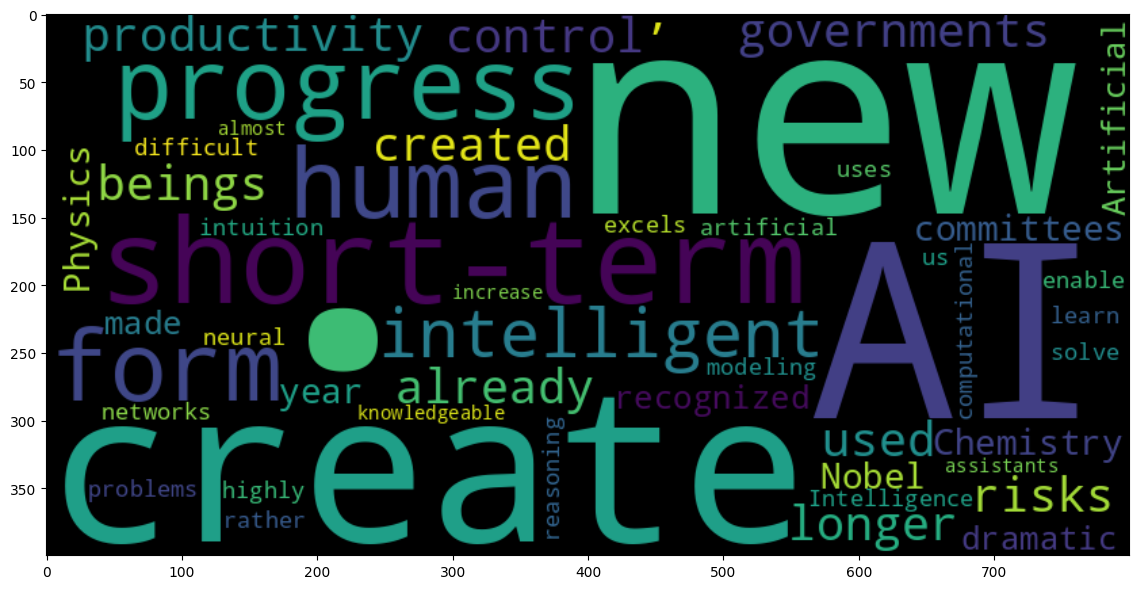

In [44]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='black',
    max_words=50,
    colormap='viridis').generate_from_frequencies(Counter(all_words))
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.tight_layout()
plt.show()